In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import classification_report, confusion_matrix

print("Libraries imported successfully.")

Original shape: (16338, 7)
Cleaned shape: (16338, 7)


In [7]:
svm_model = joblib.load("../models/best_svm_model.pkl")
tfidf_vectorizer = joblib.load("../models/best_tfidf_vectorizer.pkl")

print("SVM model loaded.")
print("TF-IDF vectorizer loaded.")

print("Number of known classes:", len(svm_model.classes_))
print("\nKnown queues:")
print(svm_model.classes_)

SVM model loaded.
TF-IDF vectorizer loaded.
Number of known classes: 10

Known queues:
['Billing and Payments' 'Customer Service' 'General Inquiry'
 'Human Resources' 'IT Support' 'Product Support' 'Returns and Exchanges'
 'Sales and Pre-Sales' 'Service Outages and Maintenance'
 'Technical Support']


In [9]:
df = pd.read_csv("../data/processed/customer_support_tickets_en.csv")

df = df.dropna(subset=["text", "queue"]).copy()

df = df[
    (df["text"].str.strip() != "") &
    (df["queue"].str.strip() != "")
].reset_index(drop=True)

print("Dataset shape:", df.shape)

Dataset shape: (16338, 7)


In [10]:
#split
from sklearn.model_selection import train_test_split

X = df["text"]
y = df["queue"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Test samples:", len(X_test))

Test samples: 3268


In [12]:
#evaluate
X_test_tfidf = tfidf_vectorizer.transform(X_test)

y_pred = svm_model.predict(X_test_tfidf)

print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

                                 precision    recall  f1-score   support

           Billing and Payments       0.88      0.89      0.89       319
               Customer Service       0.68      0.71      0.70       482
                General Inquiry       0.91      0.64      0.75        47
                Human Resources       0.96      0.70      0.81        70
                     IT Support       0.72      0.63      0.67       388
                Product Support       0.69      0.71      0.70       615
          Returns and Exchanges       0.85      0.63      0.73       164
            Sales and Pre-Sales       0.80      0.66      0.72       103
Service Outages and Maintenance       0.81      0.80      0.80       133
              Technical Support       0.71      0.79      0.75       947

                       accuracy                           0.74      3268
                      macro avg       0.80      0.72      0.75      3268
                   weighted avg       0.74      0

In [13]:
#unknown detection
novel_tickets = [
    "The new AI recommendation feature is giving completely irrelevant suggestions.",
    
    "I am having problems with the new augmented reality workspace feature.",
    
    "The newly introduced voice assistant keeps misunderstanding my commands.",
    
    "The experimental blockchain integration is failing during synchronization.",
    
    "The new recommendation engine is producing unexpected results."
]

novel_df = pd.DataFrame({
    "text": novel_tickets
})

novel_df

,text
0,The new AI recommendation feature is giving co...
1,I am having problems with the new augmented re...
2,The newly introduced voice assistant keeps mis...
3,The experimental blockchain integration is fai...
4,The new recommendation engine is producing une...


In [15]:
#Convert novel tickets to TF-IDF
novel_tfidf = tfidf_vectorizer.transform(
    novel_df["text"]
)

print("Novel tickets transformed successfully.")
print("TF-IDF shape:", novel_tfidf.shape)


novel_predictions = svm_model.predict(novel_tfidf)

novel_df["predicted_queue"] = novel_predictions

novel_df

Novel tickets transformed successfully.
TF-IDF shape: (5, 129864)


,text,predicted_queue
0,The new AI recommendation feature is giving co...,Technical Support
1,I am having problems with the new augmented re...,Product Support
2,The newly introduced voice assistant keeps mis...,Sales and Pre-Sales
3,The experimental blockchain integration is fai...,IT Support
4,The new recommendation engine is producing une...,General Inquiry


In [16]:
#decision score
decision_scores = svm_model.decision_function(novel_tfidf)

print("Decision score shape:", decision_scores.shape)

Decision score shape: (5, 10)


In [17]:
#confidence
sorted_scores = np.sort(decision_scores, axis=1)

top_score = sorted_scores[:, -1]
second_score = sorted_scores[:, -2]

margin = top_score - second_score

novel_df["confidence_margin"] = margin

novel_df

,text,predicted_queue,confidence_margin
0,The new AI recommendation feature is giving co...,Technical Support,0.027374
1,I am having problems with the new augmented re...,Product Support,0.015750
2,The newly introduced voice assistant keeps mis...,Sales and Pre-Sales,0.111257
3,The experimental blockchain integration is fai...,IT Support,0.236780
4,The new recommendation engine is producing une...,General Inquiry,0.204935


In [21]:
UNKNOWN_THRESHOLD = 0.20

novel_df["status"] = np.where(
    novel_df["confidence_margin"] < UNKNOWN_THRESHOLD,
    "UNKNOWN / REVIEW",
    "KNOWN / ROUTE"
)

novel_df


results = novel_df[
    [
        "text",
        "predicted_queue",
        "confidence_margin",
        "status"
    ]
]

results

,text,predicted_queue,confidence_margin,status
0,The new AI recommendation feature is giving co...,Technical Support,0.027374,UNKNOWN / REVIEW
1,I am having problems with the new augmented re...,Product Support,0.015750,UNKNOWN / REVIEW
2,The newly introduced voice assistant keeps mis...,Sales and Pre-Sales,0.111257,UNKNOWN / REVIEW
3,The experimental blockchain integration is fai...,IT Support,0.236780,KNOWN / ROUTE
4,The new recommendation engine is producing une...,General Inquiry,0.204935,KNOWN / ROUTE


In [22]:
#testing on normal ticktes
known_sample = X_test.sample(
    n=min(20, len(X_test)),
    random_state=42
)

known_sample_tfidf = tfidf_vectorizer.transform(
    known_sample
)

known_scores = svm_model.decision_function(
    known_sample_tfidf
)

known_sorted = np.sort(known_scores, axis=1)

known_margins = (
    known_sorted[:, -1] -
    known_sorted[:, -2]
)

known_predictions = svm_model.predict(
    known_sample_tfidf
)

known_results = pd.DataFrame({
    "text": known_sample.values,
    "predicted_queue": known_predictions,
    "confidence_margin": known_margins
})

known_results["status"] = np.where(
    known_results["confidence_margin"] < UNKNOWN_THRESHOLD,
    "UNKNOWN / REVIEW",
    "KNOWN / ROUTE"
)

known_results

,text,predicted_queue,confidence_margin,status
0,Digital Marketing Approaches Achieving Anticip...,Technical Support,0.591955,KNOWN / ROUTE
1,Concerns About Data Analytics Noted the presen...,Product Support,0.269490,KNOWN / ROUTE
2,Query for Digital Marketing Insights Is it pos...,Product Support,0.176397,UNKNOWN / REVIEW
3,Enhancement Strategies for Digital Brand Growt...,Customer Service,0.025291,UNKNOWN / REVIEW
4,Concerns Regarding Service Outage Affecting Di...,Service Outages and Maintenance,1.892865,KNOWN / ROUTE
5,Assistance Required for Expanding Digital Mark...,Returns and Exchanges,0.154754,UNKNOWN / REVIEW
6,Seeking Assistance with Integrating TensorFlow...,IT Support,1.962015,KNOWN / ROUTE
7,Enhance Project Management Software Incorporat...,Returns and Exchanges,0.115370,UNKNOWN / REVIEW
8,Several Tools Experiencing Failures Customer S...,Product Support,1.305806,KNOWN / ROUTE
9,Network Problem Important medical information ...,Technical Support,0.053238,UNKNOWN / REVIEW


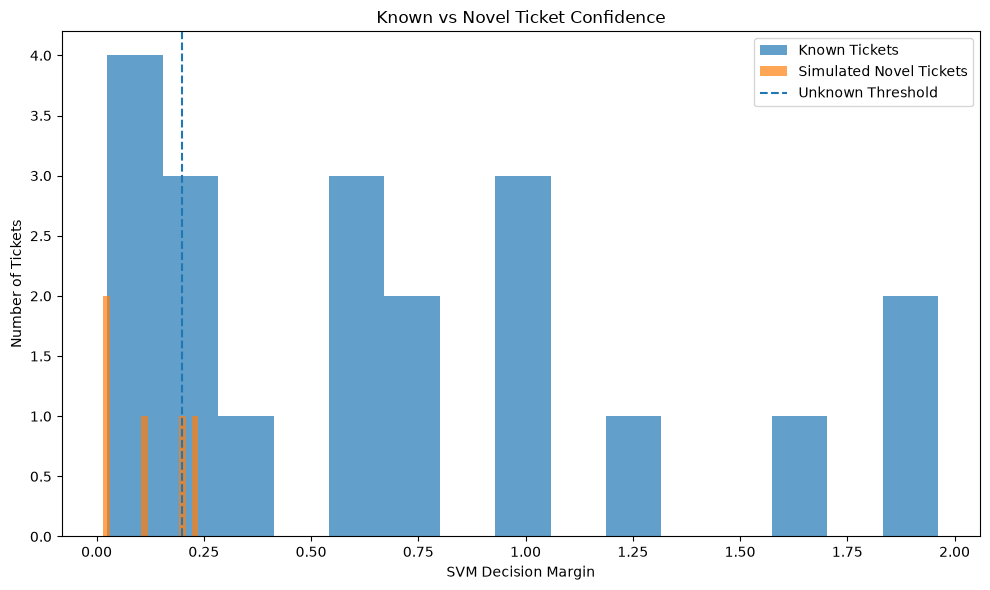

In [23]:
#Compare confidence distributions
plt.figure(figsize=(10, 6))

plt.hist(
    known_margins,
    bins=15,
    alpha=0.7,
    label="Known Tickets"
)

plt.hist(
    margin,
    bins=15,
    alpha=0.7,
    label="Simulated Novel Tickets"
)

plt.axvline(
    UNKNOWN_THRESHOLD,
    linestyle="--",
    label="Unknown Threshold"
)

plt.xlabel("SVM Decision Margin")
plt.ylabel("Number of Tickets")
plt.title("Known vs Novel Ticket Confidence")
plt.legend()

plt.tight_layout()
plt.show()

In [24]:
#saving unknown detection configurations 
import json

unknown_config = {
    "method": "SVM decision-function margin",
    "threshold": UNKNOWN_THRESHOLD,
    "description": "Tickets below this confidence margin are flagged for review."
}

with open(
    "../models/unknown_detection_config.json",
    "w"
) as f:
    json.dump(
        unknown_config,
        f,
        indent=4
    )

print("Unknown detection configuration saved.")

Unknown detection configuration saved.
